# Regresión Lineal Simple — versión examen con gráficas

Este notebook es **solo de regresión lineal simple**.

Ejemplo fácil:

> Queremos predecir los **goles** de un equipo según sus **tiros a puerta**.

Es decir:

```text
X = tiros_a_puerta
y = goles
```

La idea es hacerlo parecido al ejemplo de clase:

1. Crear datos.
2. Dibujar nube de puntos.
3. Calcular correlación.
4. Dibujar una recta a mano.
5. Entrenar regresión lineal simple.
6. Dibujar la mejor recta.
7. Dibujar el error con líneas verticales.
8. Calcular métricas.
9. Dibujar residuos.
10. Ver gráfica 3D del error.
11. Hacer una predicción nueva.
12. Escribir conclusión de examen.

## 1. Importar librerías

Esto es lo primero que necesitas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Crear datos sencillos

Cada fila representa un partido.

Usamos:

- `tiros_a_puerta`: tiros entre los tres palos.
- `goles`: goles marcados.

Queremos ver si existe relación entre tirar más a puerta y marcar más goles.

In [2]:
df = pd.DataFrame({
    "equipo": [
        "Real Madrid", "Barcelona", "Atletico", "Sevilla", "Betis",
        "Valencia", "Villarreal", "Real Sociedad", "Athletic", "Celta",
        "Getafe", "Osasuna", "Mallorca", "Girona", "Rayo",
        "Cadiz", "Alaves", "Granada", "Las Palmas", "Espanyol"
    ],
    "tiros_a_puerta": [9, 8, 6, 5, 5, 4, 6, 5, 4, 3, 2, 3, 2, 7, 4, 2, 3, 2, 4, 3],
    "goles": [4, 3, 2, 2, 1, 1, 2, 2, 1, 1, 0, 1, 0, 3, 1, 0, 1, 0, 2, 1]
})

df

,equipo,tiros_a_puerta,goles
0,Real Madrid,9,4
1,Barcelona,8,3
2,Atletico,6,2
3,Sevilla,5,2
4,Betis,5,1
5,Valencia,4,1
6,Villarreal,6,2
7,Real Sociedad,5,2
8,Athletic,4,1
9,Celta,3,1


## 3. Separar variables

En regresión lineal simple tenemos:

```text
X = variable predictora
y = variable objetivo
```

Aquí:

```text
X = tiros_a_puerta
y = goles
```

In [3]:
x = df["tiros_a_puerta"].values
y = df["goles"].values

print("x =", x)
print("y =", y)

x = [9 8 6 5 5 4 6 5 4 3 2 3 2 7 4 2 3 2 4 3]
y = [4 3 2 2 1 1 2 2 1 1 0 1 0 3 1 0 1 0 2 1]


## 4. Nube de puntos

La nube de puntos sirve para ver visualmente si hay relación.

Si los puntos suben hacia la derecha, hay relación positiva:

```text
más tiros a puerta → más goles
```

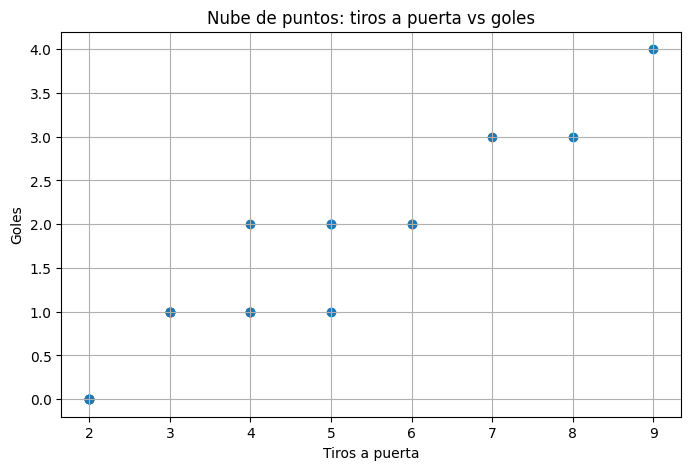

In [4]:
plt.figure(figsize=(8, 5))

plt.scatter(x, y)

plt.xlabel("Tiros a puerta")
plt.ylabel("Goles")
plt.title("Nube de puntos: tiros a puerta vs goles")

plt.grid(True)
plt.show()

### Qué escribir en el examen

```text
Primero represento la nube de puntos para observar si existe relación entre la variable predictora y la variable objetivo.

En este caso se observa una relación positiva: cuando aumentan los tiros a puerta, normalmente aumentan los goles.
```

## 5. Correlación

La correlación mide la relación entre dos variables.

- Cerca de 1: relación positiva fuerte.
- Cerca de 0: poca relación.
- Cerca de -1: relación negativa fuerte.

In [5]:
correlacion = np.corrcoef(x, y)[0, 1]

print("La correlación entre tiros a puerta y goles es:", round(correlacion, 3))

La correlación entre tiros a puerta y goles es: 0.95


### Qué escribir en el examen

```text
La correlación sirve para medir la relación entre las dos variables.

Si la correlación es positiva y alta, significa que cuando aumentan los tiros a puerta también suelen aumentar los goles.
```

## 6. Dibujar una recta a mano

Antes de usar el modelo, podemos dibujar una recta aproximada.

Una recta tiene la forma:

```text
y = b0 + b1 · x
```

Donde:

- `b0` es el intercepto.
- `b1` es la pendiente.

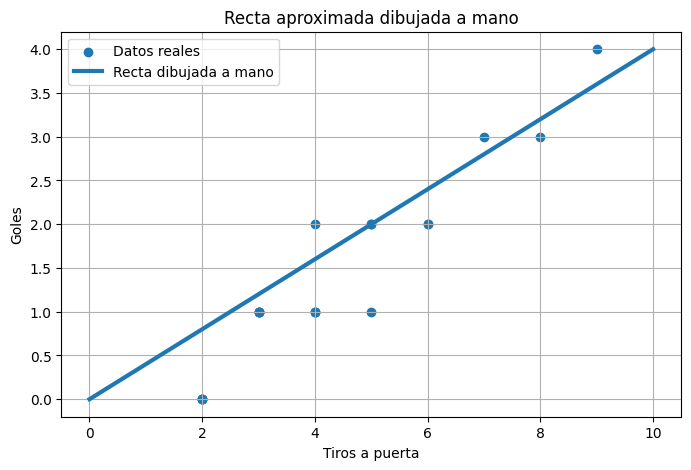

In [6]:
# Recta inventada a mano
# goles = 0 + 0.4 * tiros_a_puerta

def prediccion_manual(x):
    return 0 + 0.4 * x

x_recta = np.array([0, 10])
y_recta = prediccion_manual(x_recta)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, label="Datos reales")
plt.plot(x_recta, y_recta, linewidth=3, label="Recta dibujada a mano")

plt.xlabel("Tiros a puerta")
plt.ylabel("Goles")
plt.title("Recta aproximada dibujada a mano")
plt.legend()
plt.grid(True)
plt.show()

### Qué escribir en el examen

```text
Podemos dibujar una recta aproximada a ojo, pero esa recta no tiene por qué ser la mejor.

La regresión lineal calcula automáticamente la recta que mejor se ajusta a los puntos.
```

## 7. Error de una recta

El error o residuo es la diferencia entre el valor real y el valor predicho.

```text
error = y_real - y_predicho
```

Si el punto está lejos de la recta, el error es grande.

Si está cerca de la recta, el error es pequeño.

In [7]:
y_manual = prediccion_manual(x)
errores_manual = y - y_manual

tabla_error_manual = pd.DataFrame({
    "equipo": df["equipo"],
    "tiros_a_puerta": x,
    "goles_reales": y,
    "goles_predichos_manual": y_manual,
    "error": errores_manual
})

tabla_error_manual

,equipo,tiros_a_puerta,goles_reales,goles_predichos_manual,error
0,Real Madrid,9,4,3.6,0.4
1,Barcelona,8,3,3.2,-0.2
2,Atletico,6,2,2.4,-0.4
3,Sevilla,5,2,2.0,0.0
4,Betis,5,1,2.0,-1.0
5,Valencia,4,1,1.6,-0.6
6,Villarreal,6,2,2.4,-0.4
7,Real Sociedad,5,2,2.0,0.0
8,Athletic,4,1,1.6,-0.6
9,Celta,3,1,1.2,-0.2


## 8. Dibujar el error con líneas verticales

Las líneas verticales muestran la distancia entre:

- el valor real;
- el valor predicho por la recta.

Esa distancia es el error.

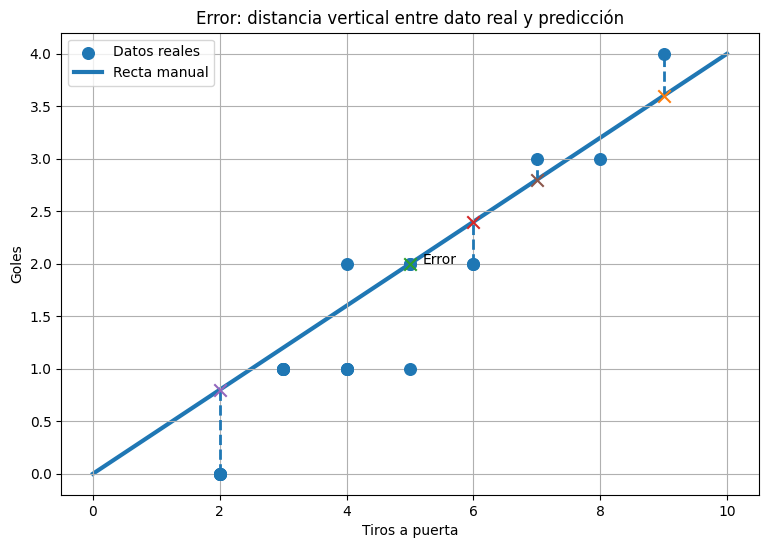

In [8]:
plt.figure(figsize=(9, 6))

# Puntos reales
plt.scatter(x, y, s=70, label="Datos reales", zorder=3)

# Recta manual
x_recta = np.array([0, 10])
y_recta = prediccion_manual(x_recta)
plt.plot(x_recta, y_recta, linewidth=3, label="Recta manual", zorder=1)

# Marcamos algunos errores
puntos_a_marcar = [0, 3, 6, 10, 13]

for i in puntos_a_marcar:
    x_punto = x[i]
    y_real = y[i]
    y_pred = prediccion_manual(x_punto)

    plt.vlines(
        x_punto,
        ymin=min(y_real, y_pred),
        ymax=max(y_real, y_pred),
        linestyle="--",
        linewidth=2,
        zorder=2
    )

    plt.scatter(x_punto, y_pred, marker="x", s=80, zorder=4)

    if i == 3:
        plt.text(x_punto + 0.2, (y_real + y_pred) / 2, "Error")

plt.xlabel("Tiros a puerta")
plt.ylabel("Goles")
plt.title("Error: distancia vertical entre dato real y predicción")
plt.legend()
plt.grid(True)
plt.show()

### Qué escribir en el examen

```text
El error se representa como la distancia vertical entre el punto real y la recta de predicción.

La regresión lineal intenta encontrar la recta que hace que esos errores sean lo más pequeños posible.
```

## 9. Entrenar la regresión lineal simple

Ahora usamos `LinearRegression`.

Para sklearn, `X` debe ser una tabla de dos dimensiones.

Por eso hacemos:

```text
X = df[['tiros_a_puerta']]
y = df['goles']
```

In [9]:
X = df[["tiros_a_puerta"]]
y = df["goles"]

modelo = LinearRegression()

modelo.fit(X, y)

print("Intercepto b0:", modelo.intercept_)
print("Pendiente b1:", modelo.coef_[0])

Intercepto b0: -0.8262253341820491
Pendiente b1: 0.5117759388924251


## 10. Fórmula del modelo

La fórmula queda así:

```text
goles = b0 + b1 · tiros_a_puerta
```

El modelo calcula automáticamente `b0` y `b1`.

In [10]:
b0 = modelo.intercept_
b1 = modelo.coef_[0]

print(f"goles = {b0:.3f} + {b1:.3f} · tiros_a_puerta")

goles = -0.826 + 0.512 · tiros_a_puerta


### Qué escribir en el examen

```text
He creado un modelo LinearRegression y lo he entrenado con fit(X, y).

El modelo obtiene una recta de la forma y = b0 + b1·x.

El intercepto b0 indica el valor inicial de la predicción.

La pendiente b1 indica cuánto aumentan los goles predichos por cada tiro a puerta adicional.
```

## 11. Dibujar la mejor recta de regresión

Esta es la recta calculada por el modelo.

Es mejor que la recta a mano porque minimiza los errores.

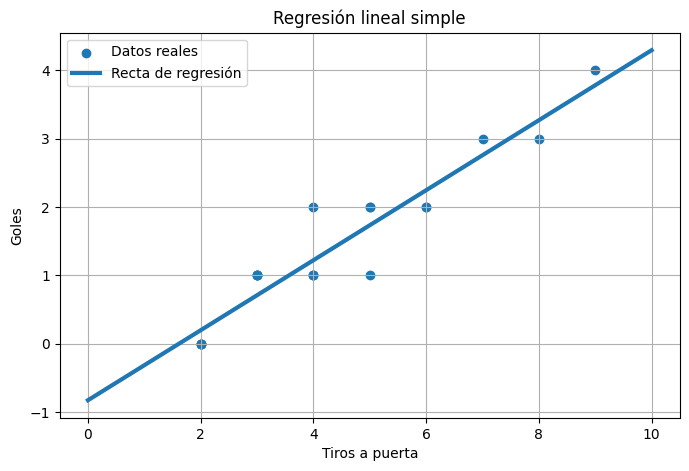

In [11]:
x_linea = np.linspace(0, 10, 100)
X_linea = pd.DataFrame({"tiros_a_puerta": x_linea})
y_linea = modelo.predict(X_linea)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, label="Datos reales")
plt.plot(x_linea, y_linea, linewidth=3, label="Recta de regresión")

plt.xlabel("Tiros a puerta")
plt.ylabel("Goles")
plt.title("Regresión lineal simple")
plt.legend()
plt.grid(True)
plt.show()

## 12. Predicciones del modelo

Ahora calculamos los goles predichos para cada partido.

In [12]:
y_pred = modelo.predict(X)

comparacion = pd.DataFrame({
    "equipo": df["equipo"],
    "tiros_a_puerta": df["tiros_a_puerta"],
    "goles_reales": y,
    "goles_predichos": y_pred,
    "error_residuo": y - y_pred
})

comparacion

,equipo,tiros_a_puerta,goles_reales,goles_predichos,error_residuo
0,Real Madrid,9,4,3.779758,0.220242
1,Barcelona,8,3,3.267982,-0.267982
2,Atletico,6,2,2.244430,-0.244430
3,Sevilla,5,2,1.732654,0.267346
4,Betis,5,1,1.732654,-0.732654
5,Valencia,4,1,1.220878,-0.220878
6,Villarreal,6,2,2.244430,-0.244430
7,Real Sociedad,5,2,1.732654,0.267346
8,Athletic,4,1,1.220878,-0.220878
9,Celta,3,1,0.709102,0.290898


## 13. Gráfica de la recta con errores del modelo

Ahora las líneas verticales muestran el error usando la recta buena, no la recta manual.

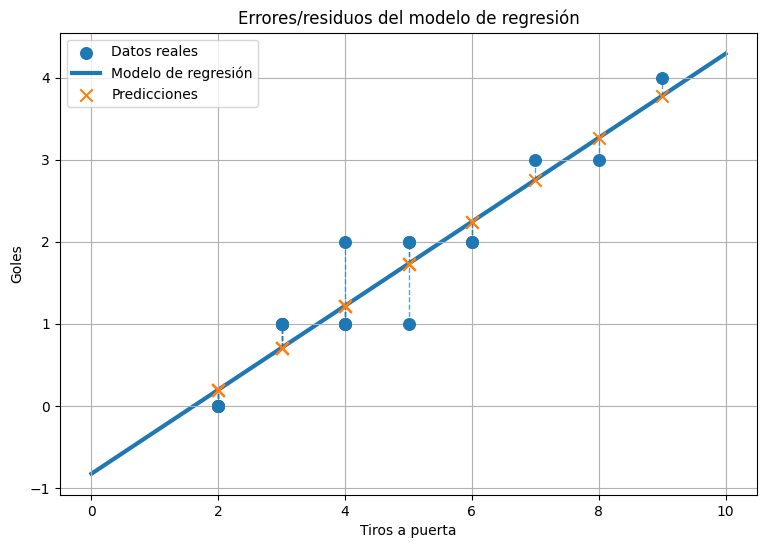

In [13]:
plt.figure(figsize=(9, 6))

# Datos reales
plt.scatter(x, y, s=70, label="Datos reales", zorder=3)

# Recta del modelo
plt.plot(x_linea, y_linea, linewidth=3, label="Modelo de regresión", zorder=1)

# Predicciones sobre los datos reales
plt.scatter(x, y_pred, marker="x", s=80, label="Predicciones", zorder=4)

# Dibujar residuos para todos los puntos
for i in range(len(x)):
    plt.vlines(
        x[i],
        ymin=min(y.iloc[i], y_pred[i]),
        ymax=max(y.iloc[i], y_pred[i]),
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        zorder=2
    )

plt.xlabel("Tiros a puerta")
plt.ylabel("Goles")
plt.title("Errores/residuos del modelo de regresión")
plt.legend()
plt.grid(True)
plt.show()

### Qué escribir en el examen

```text
Cada línea vertical representa un residuo.

Un residuo es la diferencia entre el valor real y la predicción.

Si las líneas son pequeñas, el modelo predice bien.

Si las líneas son grandes, el modelo se equivoca más.
```

## 14. Métricas del modelo

Calculamos:

- `R2`: mide qué parte de la variación de los goles explica el modelo.
- `MAE`: error absoluto medio.
- `MSE`: error cuadrático medio.
- `RMSE`: raíz del MSE.

In [14]:
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("R2:", round(r2, 3))
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))

R2: 0.902
MAE: 0.294
MSE: 0.111
RMSE: 0.334


### Qué escribir en el examen

```text
R2 indica qué parte de la variación de los goles explica el modelo. Cuanto más cerca de 1, mejor.

MAE indica cuánto se equivoca el modelo de media. Si MAE vale 0.3, el modelo se equivoca de media en 0.3 goles.

MSE penaliza más los errores grandes.

RMSE es la raíz del MSE y se interpreta en las mismas unidades que la variable objetivo, en este caso goles.

Un buen modelo tiene R2 alto y MAE/RMSE bajos.
```

## 15. Gráfica de residuos

Un residuo es:

```text
residuo = valor real - valor predicho
```

En esta gráfica:

- Eje X: predicciones.
- Eje Y: residuos.

La línea horizontal en 0 representa error cero.

Lo ideal es que los residuos estén repartidos alrededor de 0.

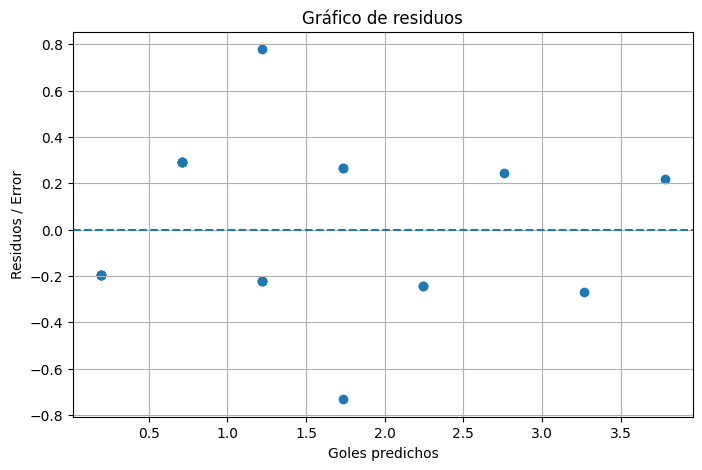

In [15]:
residuos = y - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuos)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Goles predichos")
plt.ylabel("Residuos / Error")
plt.title("Gráfico de residuos")
plt.grid(True)
plt.show()

### Qué escribir en el examen

```text
El gráfico de residuos sirve para analizar los errores del modelo.

Si los residuos aparecen repartidos alrededor de cero, el modelo se comporta de forma razonable.

Si aparece un patrón claro, puede significar que la relación no es completamente lineal.
```

## 16. Gráfica de valores reales vs predichos

Esta gráfica compara:

- goles reales;
- goles predichos.

Si el modelo fuera perfecto, todos los puntos caerían sobre la línea diagonal.

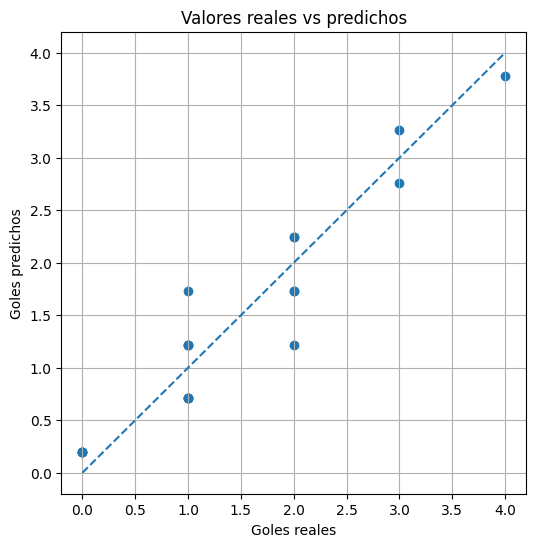

In [16]:
plt.figure(figsize=(6, 6))

plt.scatter(y, y_pred)

minimo = min(y.min(), y_pred.min())
maximo = max(y.max(), y_pred.max())

plt.plot([minimo, maximo], [minimo, maximo], linestyle="--")

plt.xlabel("Goles reales")
plt.ylabel("Goles predichos")
plt.title("Valores reales vs predichos")
plt.grid(True)
plt.show()

## 17. Gráfica 3D de la función de error

Esta gráfica sirve para entender qué hace la regresión lineal.

La regresión lineal busca los valores de:

```text
b0 = intercepto
b1 = pendiente
```

que consiguen el menor error posible.

En la gráfica 3D:

- Eje X: pendiente `b1`.
- Eje Y: intercepto `b0`.
- Eje Z: error MSE.

El punto más bajo es la mejor recta.

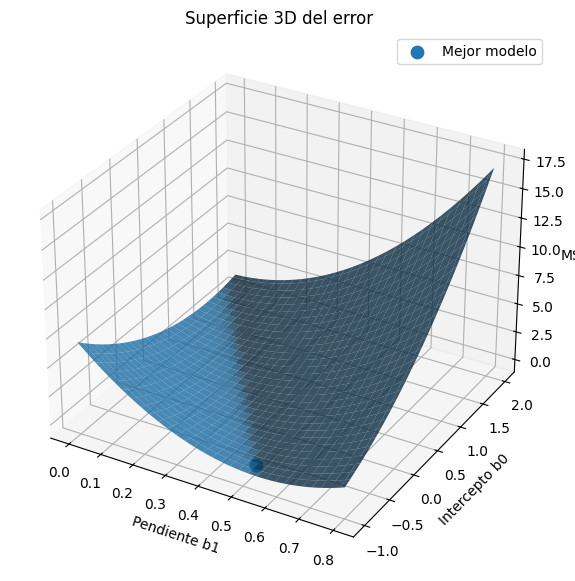

In [17]:
# Creamos valores posibles para b0 y b1
b0_valores = np.linspace(-1, 2, 60)
b1_valores = np.linspace(0, 0.8, 60)

B0, B1 = np.meshgrid(b0_valores, b1_valores)

MSE = np.zeros_like(B0)

# Calculamos el MSE para cada combinación de b0 y b1
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        pred = B0[i, j] + B1[i, j] * x
        MSE[i, j] = np.mean((y - pred) ** 2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(B1, B0, MSE, alpha=0.8)

# Punto del modelo real
ax.scatter(b1, b0, mse, s=80, label="Mejor modelo")

ax.set_xlabel("Pendiente b1")
ax.set_ylabel("Intercepto b0")
ax.set_zlabel("MSE")
ax.set_title("Superficie 3D del error")

plt.legend()
plt.show()

### Qué escribir en el examen

```text
La gráfica 3D muestra cómo cambia el error según el intercepto y la pendiente.

La regresión lineal busca la combinación de intercepto y pendiente que minimiza el error MSE.

El punto más bajo de la superficie representa la mejor recta de regresión.
```

## 18. Predicción nueva

Ejemplo:

Un equipo hace 7 tiros a puerta.

Queremos predecir cuántos goles marcará.

In [18]:
nuevo_partido = pd.DataFrame({
    "tiros_a_puerta": [7]
})

prediccion = modelo.predict(nuevo_partido)

print("Predicción exacta:", prediccion[0])
print("Predicción redondeada:", round(prediccion[0]))

Predicción exacta: 2.7562062380649266
Predicción redondeada: 3


### Qué escribir en el examen

```text
Para hacer una predicción nueva, creo un DataFrame con la misma columna que X.

Después uso modelo.predict().

El resultado es el número de goles estimado por el modelo.
```

# Plantilla final para examen

Esta es la estructura rápida que deberías recordar.

In [19]:
# 1. Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 2. Crear o cargar datos
# df = pd.read_csv("archivo.csv")

# 3. Separar X e y
# X = df[["variable_predictora"]]
# y = df["variable_objetivo"]

# 4. Crear modelo
# modelo = LinearRegression()

# 5. Entrenar modelo
# modelo.fit(X, y)

# 6. Predecir
# y_pred = modelo.predict(X)

# 7. Evaluar
# r2 = r2_score(y, y_pred)
# mae = mean_absolute_error(y, y_pred)
# mse = mean_squared_error(y, y_pred)
# rmse = np.sqrt(mse)

# 8. Mostrar resultados
# print("Intercepto:", modelo.intercept_)
# print("Pendiente:", modelo.coef_[0])
# print("R2:", r2)
# print("MAE:", mae)
# print("MSE:", mse)
# print("RMSE:", rmse)

# 9. Gráfica
# plt.scatter(X, y)
# plt.plot(X, y_pred)
# plt.show()

# Explicación final para copiar en el examen

```text
En este ejercicio he aplicado una regresión lineal simple.

La variable predictora X es tiros_a_puerta y la variable objetivo y es goles.

Primero he representado la nube de puntos para comprobar si existe relación entre ambas variables.

Después he calculado la correlación para medir la fuerza de esa relación.

A continuación he creado un modelo LinearRegression y lo he entrenado con fit(X, y).

El modelo obtiene una recta de la forma y = b0 + b1·x.

El intercepto b0 indica el valor inicial de la predicción.

La pendiente b1 indica cuánto cambian los goles predichos cuando aumenta en una unidad el número de tiros a puerta.

Después he usado predict para obtener las predicciones.

He calculado los residuos como la diferencia entre los valores reales y los valores predichos.

También he evaluado el modelo usando R2, MAE, MSE y RMSE.

R2 indica qué parte de la variación de los goles explica el modelo. Cuanto más cerca de 1, mejor.

MAE indica cuánto se equivoca el modelo de media.

RMSE indica el error típico del modelo en goles.

La gráfica de residuos permite comprobar si los errores se distribuyen alrededor de cero.

La gráfica 3D de la función de error muestra que la regresión lineal busca la pendiente y el intercepto que minimizan el error MSE.

En conclusión, la regresión lineal simple permite predecir los goles de un equipo a partir de sus tiros a puerta.
```

# Chuleta muy corta

```text
Regresión lineal simple = una X para predecir una y.

X = tiros_a_puerta
y = goles

Modelo:
goles = b0 + b1 · tiros_a_puerta

fit() entrena.
predict() predice.

Residuo = valor real - valor predicho.

R2 alto = mejor.
MAE y RMSE bajos = mejor.

La recta buena es la que minimiza los errores.
```